# Instalar dependencias

In [1]:
!pip install opencv-python scikit-learn pillow matplotlib

# Subir imagen satelital

In [3]:
from google.colab import files

uploaded = files.upload()

Saving 1280px-The_San_Bernardo_Archipelago_in_the_Caribbean_Sea_(Copernicus_2024-01-13).jpg to 1280px-The_San_Bernardo_Archipelago_in_the_Caribbean_Sea_(Copernicus_2024-01-13).jpg


# Cargar y visualizar la imagen

In [5]:
import os

print(os.listdir())

['.config', '1280px-The_San_Bernardo_Archipelago_in_the_Caribbean_Sea_(Copernicus_2024-01-13).jpg', 'sample_data']


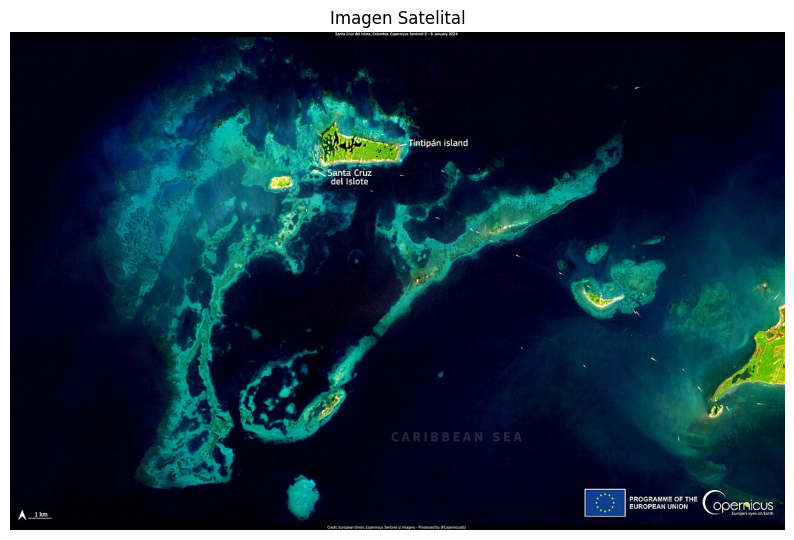

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("1280px-The_San_Bernardo_Archipelago_in_the_Caribbean_Sea_(Copernicus_2024-01-13).jpg")

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10,8))
plt.imshow(image_rgb)
plt.title("Imagen Satelital")
plt.axis("off")
plt.show()

# Seleccionar una Región de Interés (ROI)

In [7]:
x = 200
y = 150

w = 300
h = 300

Extraer ROI:

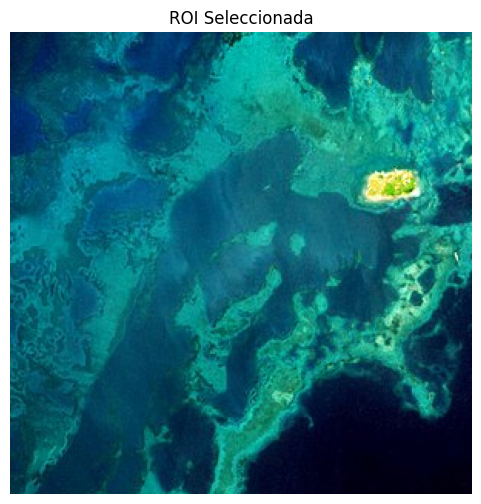

In [8]:
roi = image_rgb[
    y:y+h,
    x:x+w
]

plt.figure(figsize=(6,6))
plt.imshow(roi)
plt.title("ROI Seleccionada")
plt.axis("off")
plt.show()

# Aplicar Segmentación con K-Means

In [9]:
from sklearn.cluster import KMeans

pixels = roi.reshape((-1,3))

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(pixels)

segmented = kmeans.labels_.reshape(
    roi.shape[:2]
)

# Visualizar las clases encontradas

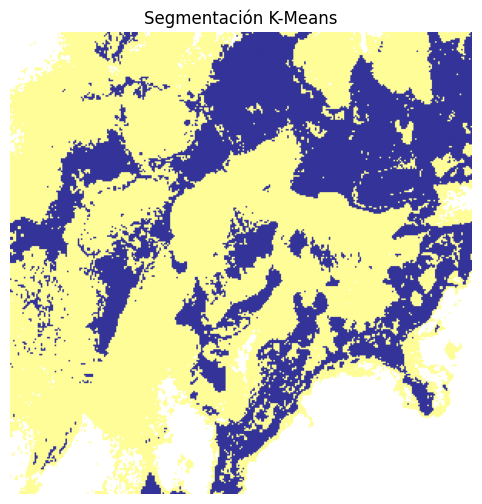

In [10]:
plt.figure(figsize=(8,6))

plt.imshow(
    segmented,
    cmap="terrain"
)

plt.title("Segmentación K-Means")
plt.axis("off")

plt.show()

# Asignar colores temáticos

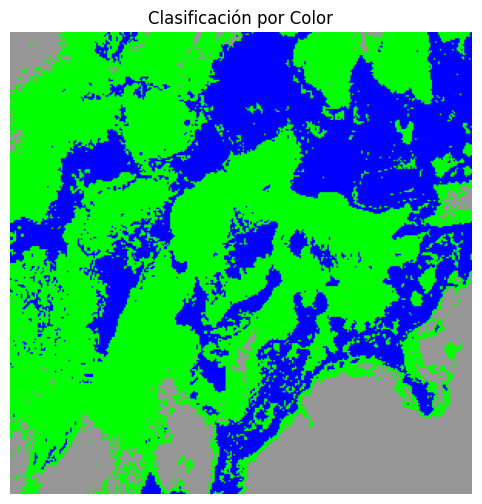

In [11]:
class_colors = np.array([
    [0,0,255],
    [0,255,0],
    [150,150,150]
], dtype=np.uint8)

colored_segmentation = class_colors[
    segmented
]

plt.figure(figsize=(8,6))

plt.imshow(colored_segmentation)

plt.title("Clasificación por Color")
plt.axis("off")

plt.show()

# Crear máscaras por clase

In [12]:
water_mask = (
    segmented == 0
).astype(np.uint8)*255

forest_mask = (
    segmented == 1
).astype(np.uint8)*255

urban_mask = (
    segmented == 2
).astype(np.uint8)*255

Visualizar

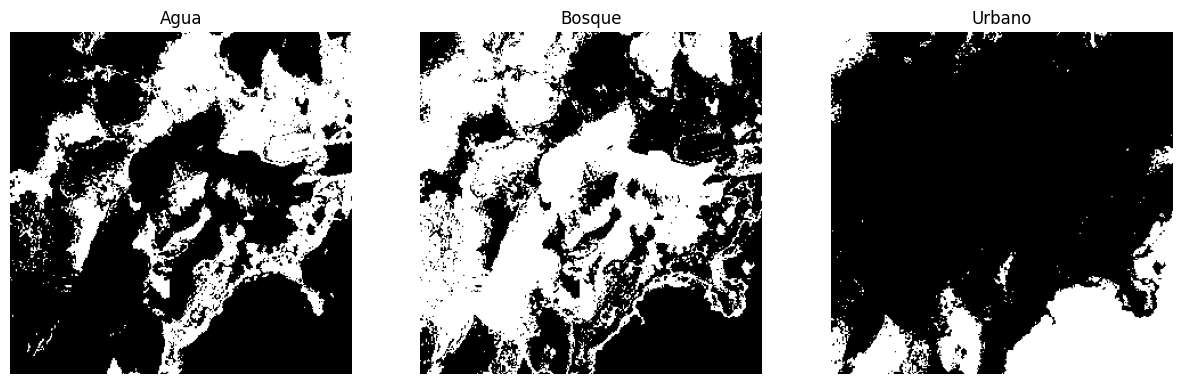

In [13]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

ax[0].imshow(water_mask,cmap="gray")
ax[0].set_title("Agua")

ax[1].imshow(forest_mask,cmap="gray")
ax[1].set_title("Bosque")

ax[2].imshow(urban_mask,cmap="gray")
ax[2].set_title("Urbano")

for a in ax:
    a.axis("off")

plt.show()

# Detectar contornos

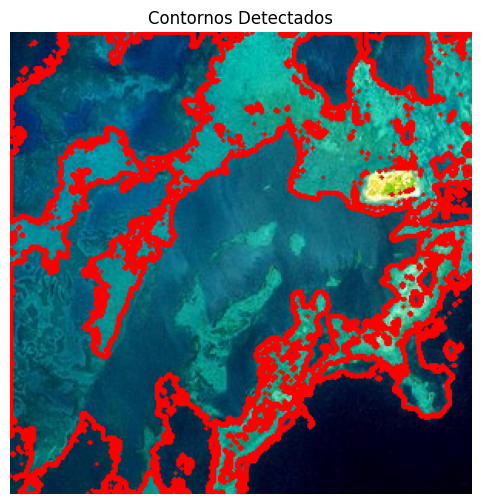

In [14]:
contours, _ = cv2.findContours(
    forest_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

roi_contours = roi.copy()

cv2.drawContours(
    roi_contours,
    contours,
    -1,
    (255,0,0),
    2
)

plt.figure(figsize=(8,6))

plt.imshow(roi_contours)

plt.title("Contornos Detectados")
plt.axis("off")

plt.show()

# Guardar resultados

In [15]:
cv2.imwrite(
    "agua.png",
    water_mask
)

cv2.imwrite(
    "bosque.png",
    forest_mask
)

cv2.imwrite(
    "urbano.png",
    urban_mask
)

cv2.imwrite(
    "segmentacion_coloreada.png",
    cv2.cvtColor(
        colored_segmentation,
        cv2.COLOR_RGB2BGR
    )
)

print("Archivos guardados")

Archivos guardados


In [16]:
from google.colab import files

files.download("agua.png")
files.download("bosque.png")
files.download("urbano.png")
files.download("segmentacion_coloreada.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Bonus: Segmentación por Umbral

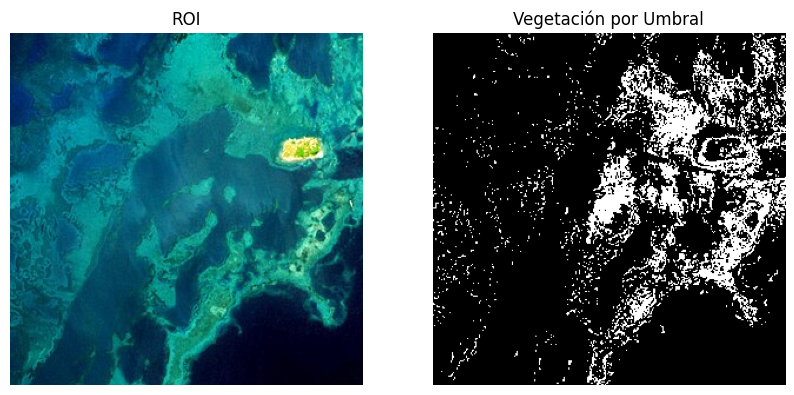

In [17]:
lower_green = np.array([
    20,
    60,
    20
])

upper_green = np.array([
    180,
    255,
    180
])

vegetation_mask = cv2.inRange(
    roi,
    lower_green,
    upper_green
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(roi)
plt.title("ROI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(
    vegetation_mask,
    cmap="gray"
)

plt.title("Vegetación por Umbral")
plt.axis("off")

plt.show()

# Celda Final de Comparación

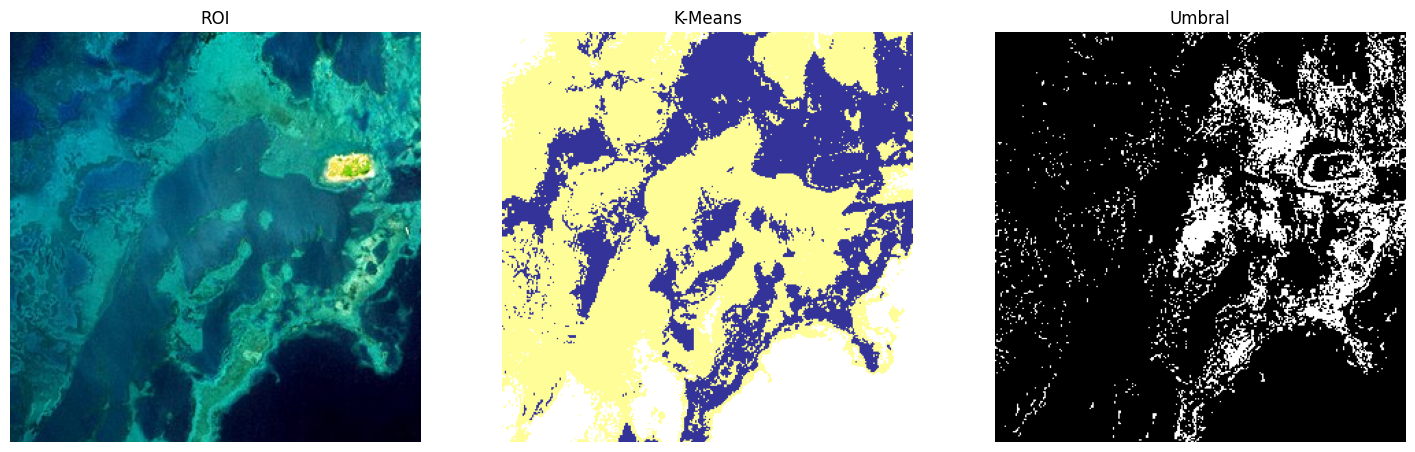

In [18]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

ax[0].imshow(roi)
ax[0].set_title("ROI")

ax[1].imshow(
    segmented,
    cmap="terrain"
)
ax[1].set_title("K-Means")

ax[2].imshow(
    vegetation_mask,
    cmap="gray"
)
ax[2].set_title("Umbral")

for a in ax:
    a.axis("off")

plt.show()